In [1]:
%load_ext cuml.accel
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR, OneCycleLR
from torch.utils.data import DataLoader, ConcatDataset
import re
import copy
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from cuml.manifold import TSNE, UMAP
from joblib import Parallel, delayed
from tqdm import tqdm

In [2]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [3]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

In [4]:
class MaskedAugmentationSpeckleFill:
    """
    Computes Choi segmentation mask on the pre-augmentation image,
    applies augmentation, then masks the result to target+shadow only.
    
    Pipeline: log_mapped_img → compute mask → aug → apply mask
    
    Args:
        augmentation: SSRAugmentation, GaussianNoise, or any transform
                      that accepts (image, filepath) tuples
    """
    def __init__(self, augmentation, fill=np.mean, ray_sigma = 0.1):
        self.aug = augmentation
        self.fill = fill
        self.ray_sigma = ray_sigma

    def __call__(self, img_or_tuple):
        if isinstance(img_or_tuple, tuple):
            image, filepath = img_or_tuple
        else:
            # Can't segment without filepath context; passthrough
            return img_or_tuple

        # Step 1: compute mask on ORIGINAL log-mapped image
        M_target, M_shadow, _ = choi_segmentation(image, high = 95, low = 25)
        mask = (M_target + M_shadow)   # binary, {0, 1}

        # Step 2: apply augmentation
        aug_result = self.aug((image, filepath))
        aug_image = aug_result[0] if isinstance(aug_result, tuple) else aug_result
        fp = aug_result[1] if isinstance(aug_result, tuple) else filepath
        
        # Step 3: apply mask + fill using augmented image statistics
        if mask.any():
            target_shadow_pixels = aug_image[mask == 1]
            fill_val = self.fill(target_shadow_pixels) if callable(self.fill) else float(self.fill)
        else:
            fill_val = 0.0
        
        synthetic_clutter = np.random.rayleigh(self.ray_sigma, size=aug_image.shape).astype(np.float32)

        result = aug_image * mask + ((fill_val + synthetic_clutter)* (1 - mask))

        return (result.astype(np.float32), fp)

In [5]:
seg_synth_ds = synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose(
        [Magnitude(), 
         LogMapping(c = 1000.0), 
         MaskedAugmentation(augmentation = identity, fill = np.mean),
         NumpyToTensor3Channel()]
    ),
    loader = mat_file_loader
)

seg_speckle_synth_ds = synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose(
        [Magnitude(), 
         LogMapping(c = 1000.0), 
         MaskedAugmentationSpeckleFill(augmentation = identity, fill = np.mean, ray_sigma = 0.1),
         NumpyToTensor3Channel()]
    ),
    loader = mat_file_loader
)

meas_ds = datasets.DatasetFolder(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [6]:
train_ds = filter_by_elev(seg_speckle_synth_ds, {14, 15, 16})
valid_ds = filter_by_elev(meas_ds, {14, 15, 16})
test_ds  = filter_by_elev(meas_ds, {17})

In [7]:
dataset_sizes = {"train" : len(train_ds), "val": len(valid_ds), "test": len(test_ds)}

seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]

train_loss = []
val_loss = []
train_acc =[]
val_acc = []

for i, seed in enumerate(seed_lst):
    print(f"Training Run {i}: seed {seed}")

    set_seed(seed)

    dataloaders = {
        "train": DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=12, pin_memory = True, persistent_workers=True, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "val": DataLoader(valid_ds, batch_size=16, shuffle=False, num_workers=12, pin_memory = True, persistent_workers=True, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "test": DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=12, pin_memory = True, persistent_workers=True, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed))
    }
    # load pre-trained model
    model = models.resnet18(weights = None)

    # Replace final layer for the number of classes
    model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(model.fc.in_features, len(train_ds.class_to_idx))
    )
    
    # Define the loss function and optimizer
    criterion = nn.CrossEntropyLoss() # most common used nn for classification problems
    
    optimizer = optim.AdamW(model.parameters(), lr = 3e-4, weight_decay = 2e-4)
    
    scheduler = CosineAnnealingLR(optimizer, T_max = 200, eta_min = 3e-7)
        
    # move model to GPU
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    history = {
        "train_loss": [],
        "val_loss" : [],
        "train_acc": [],
        "val_acc" : []
    }
    
    # Training loops
    num_epochs = 200
    for epoch in range(num_epochs):
        print(f"Epoch {epoch}")
        if epoch == 0:
            print(f"First layer mean: {model.conv1.weight.data.mean():.6f}")
        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()
    
            running_loss = 0.0
            running_corrects = 0 # correct predictions
    
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
    
                optimizer.zero_grad() # clear the gradient from previous iteration
    
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels) # check if output and labels match
    
                    if phase == "train":
                        loss.backward()
                        optimizer.step()
                        # scheduler.step() # scheduler here if OneCycleLR
    
                running_loss += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()
    
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]
            
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)
    
            print(f"{phase} Loss: {epoch_loss:.10f} Acc: {epoch_acc:.10f}")
    
        scheduler.step()
        print(f"Epoch {epoch} LR: {scheduler.get_last_lr()[0]:.10f}")
        
    print("Training complete!")
    
    train_loss.append(history["train_loss"])
    val_loss.append(history["val_loss"])
    train_acc.append(history["train_acc"])
    val_acc.append(history["val_acc"])
    
    torch.save(model.state_dict(), os.path.join(workspace, f"weights/SSR/Segmentation/Choi/wo_aug/rn18_seed{seed}_b16_speckle.pth"))

train_loss = np.array(train_loss)
val_loss = np.array(val_loss)
train_acc = np.array(train_acc)
val_acc = np.array(val_acc)

Training Run 0: seed 10
Epoch 0
First layer mean: 0.000224
train Loss: 0.9609651045 Acc: 0.6712158809
val Loss: 6.0531889867 Acc: 0.0930521092
Epoch 0 LR: 0.0002999815
Epoch 1
train Loss: 0.1443908546 Acc: 0.9565756824
val Loss: 3.1908964537 Acc: 0.0843672457
Epoch 1 LR: 0.0002999261
Epoch 2
train Loss: 0.0267134014 Acc: 0.9962779156
val Loss: 1.8252921211 Acc: 0.3300248139
Epoch 2 LR: 0.0002998336
Epoch 3
train Loss: 0.0115651234 Acc: 1.0000000000
val Loss: 2.3113442044 Acc: 0.2245657568
Epoch 3 LR: 0.0002997043
Epoch 4
train Loss: 0.0439819256 Acc: 0.9863523573
val Loss: 2.1566580578 Acc: 0.4255583127
Epoch 4 LR: 0.0002995381
Epoch 5
train Loss: 0.0453304936 Acc: 0.9875930521
val Loss: 1.8909776669 Acc: 0.3411910670
Epoch 5 LR: 0.0002993350
Epoch 6
train Loss: 0.0268201233 Acc: 0.9962779156
val Loss: 2.1192956633 Acc: 0.2791563275
Epoch 6 LR: 0.0002990950
Epoch 7
train Loss: 0.0056277921 Acc: 0.9987593052
val Loss: 1.8556403199 Acc: 0.3846153846
Epoch 7 LR: 0.0002988184
Epoch 8
train

## Mean Fill

In [8]:
# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: Seed {seed}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    )
    
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Segmentation/Choi/wo_aug/rn18_seed{seed}_b16.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0: Seed 10
Test Accuracy: 0.6048
Evaluating Run 1: Seed 42
Test Accuracy: 0.4935
Evaluating Run 2: Seed 100
Test Accuracy: 0.3673
Evaluating Run 3: Seed 123
Test Accuracy: 0.5306
Evaluating Run 4: Seed 666
Test Accuracy: 0.5121
Evaluating Run 5: Seed 777
Test Accuracy: 0.3748
Evaluating Run 6: Seed 849
Test Accuracy: 0.4434
Evaluating Run 7: Seed 1000
Test Accuracy: 0.4842
Evaluating Run 8: Seed 1111
Test Accuracy: 0.4007
Evaluating Run 9: Seed 1234
Test Accuracy: 0.3414


In [9]:
test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Min: 34.1373
Max: 60.4824
Avg, Std: 45.5288, 7.9916


## Mean Fill + Rayleigh, sigma = 0.1

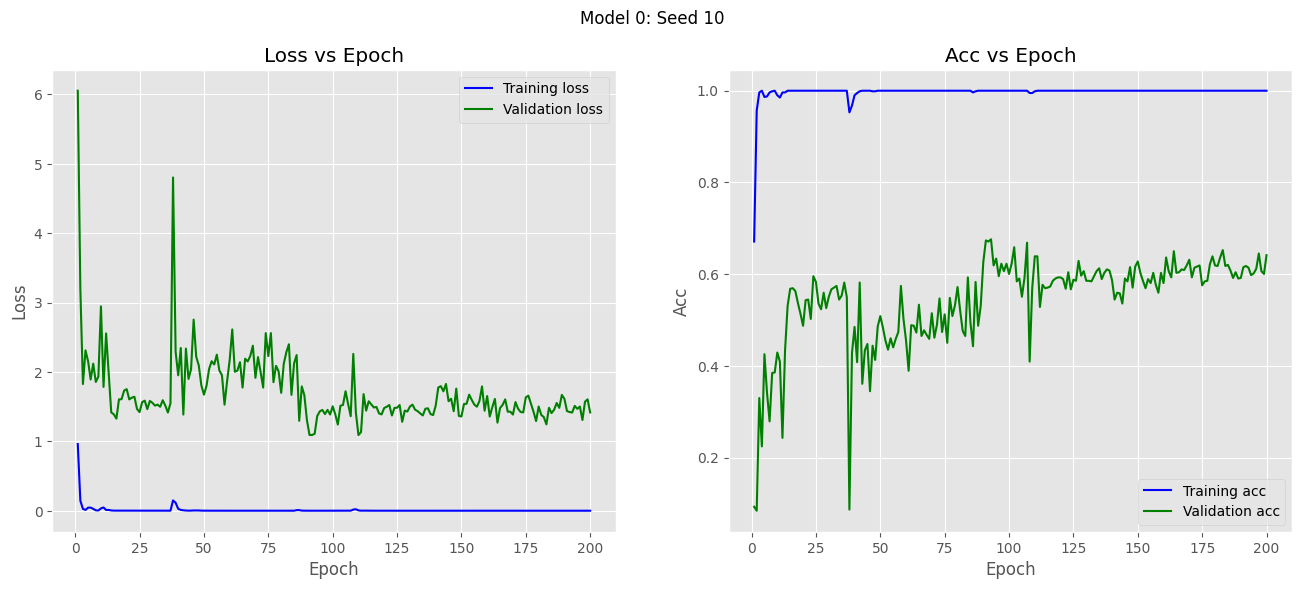

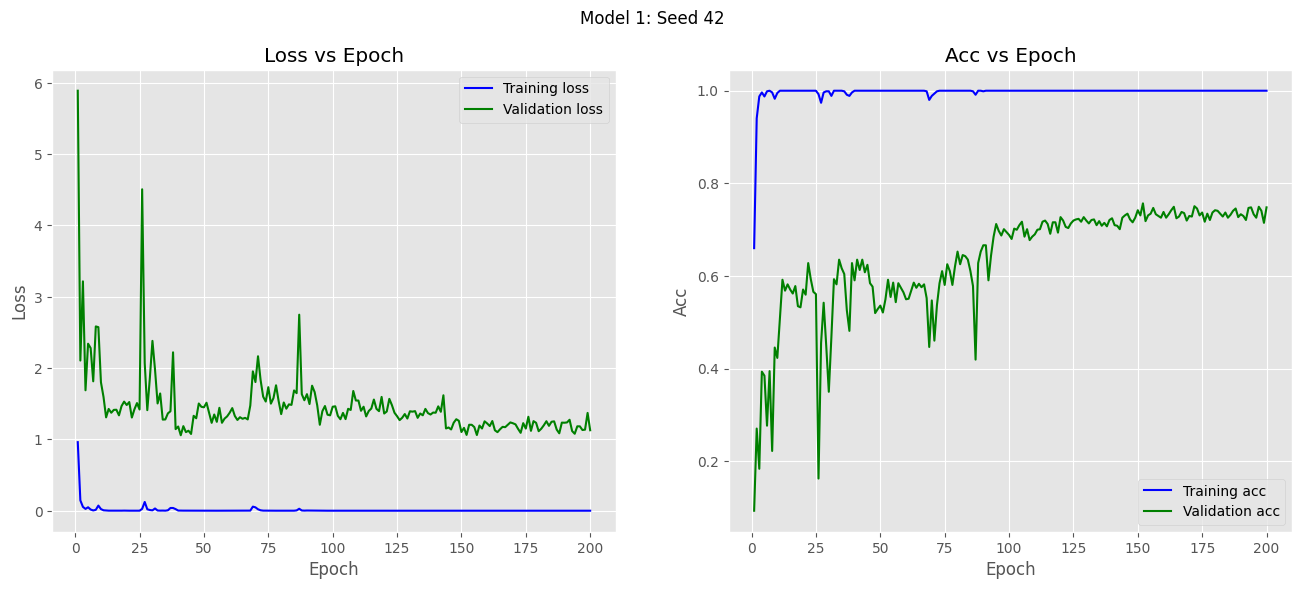

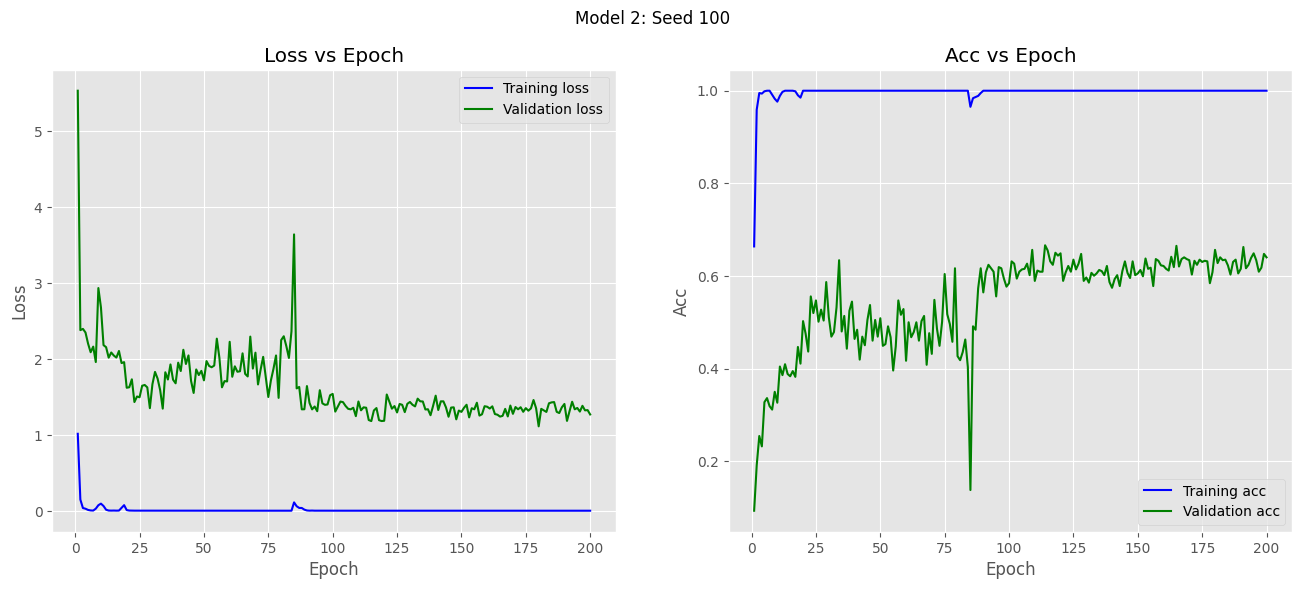

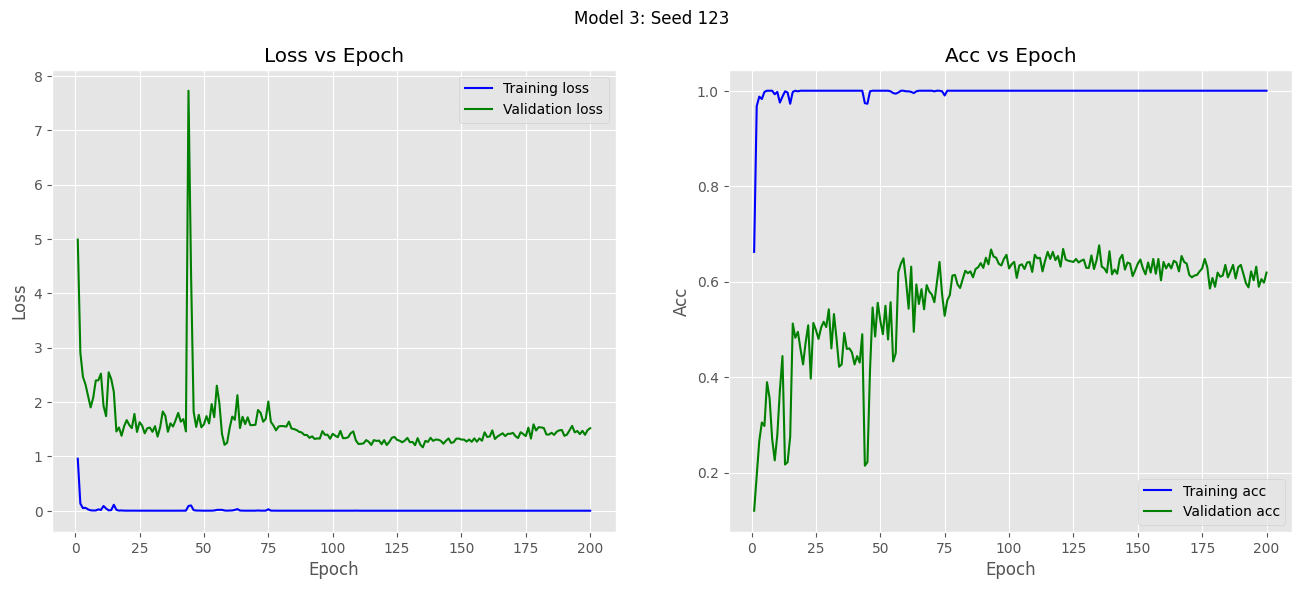

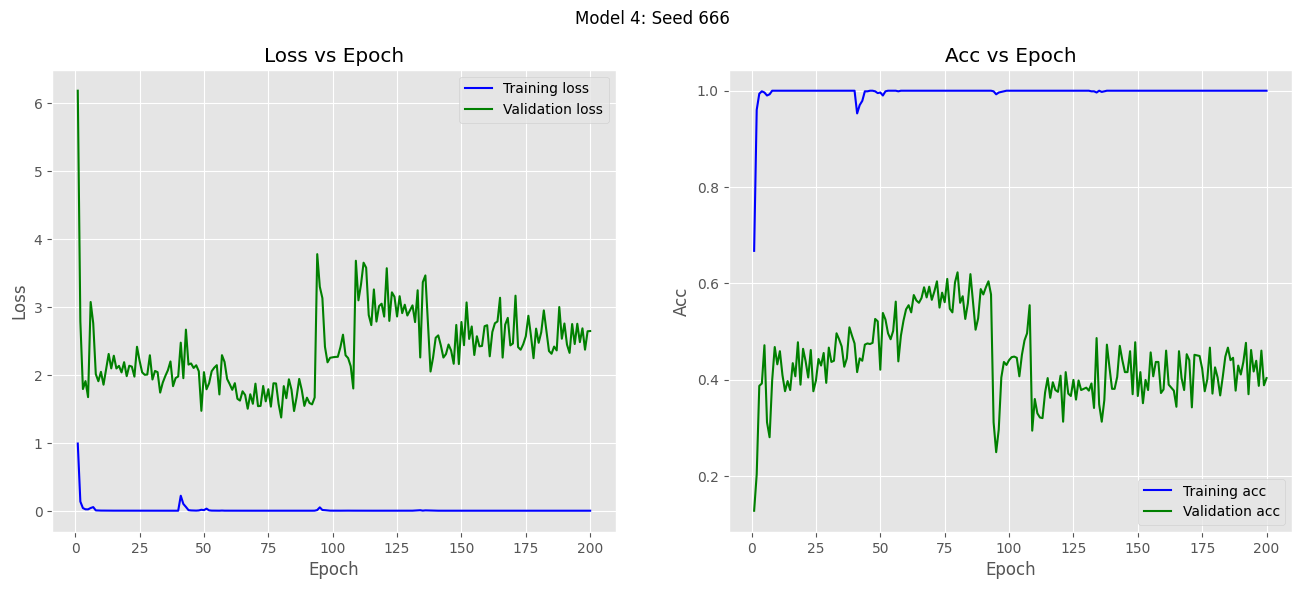

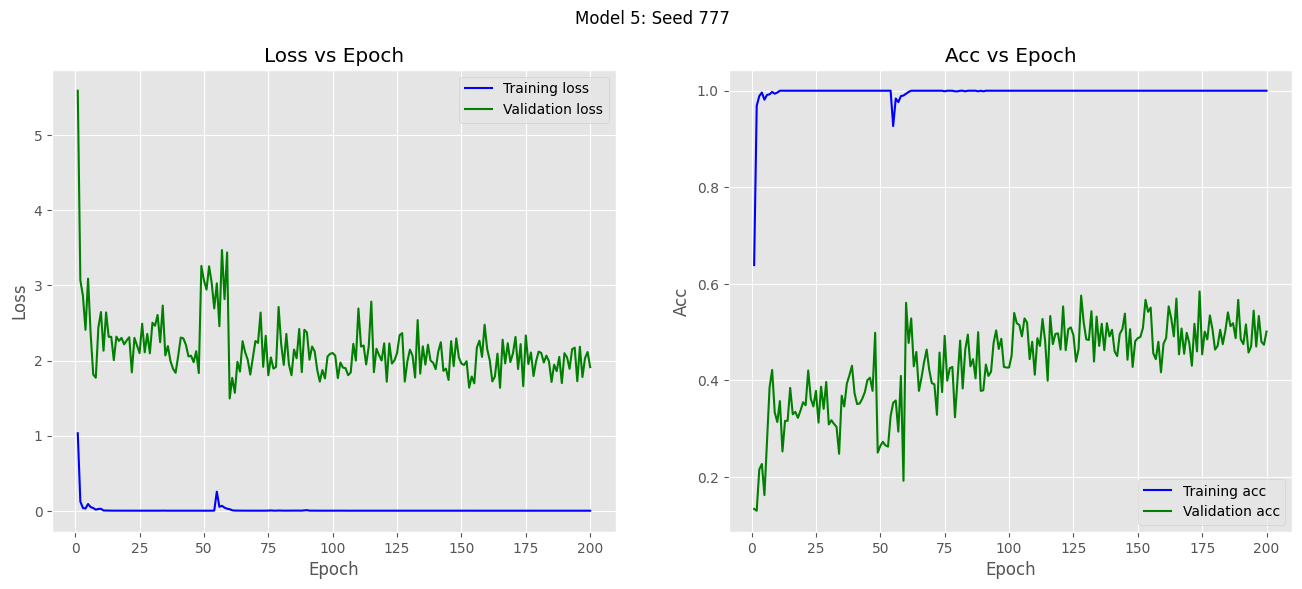

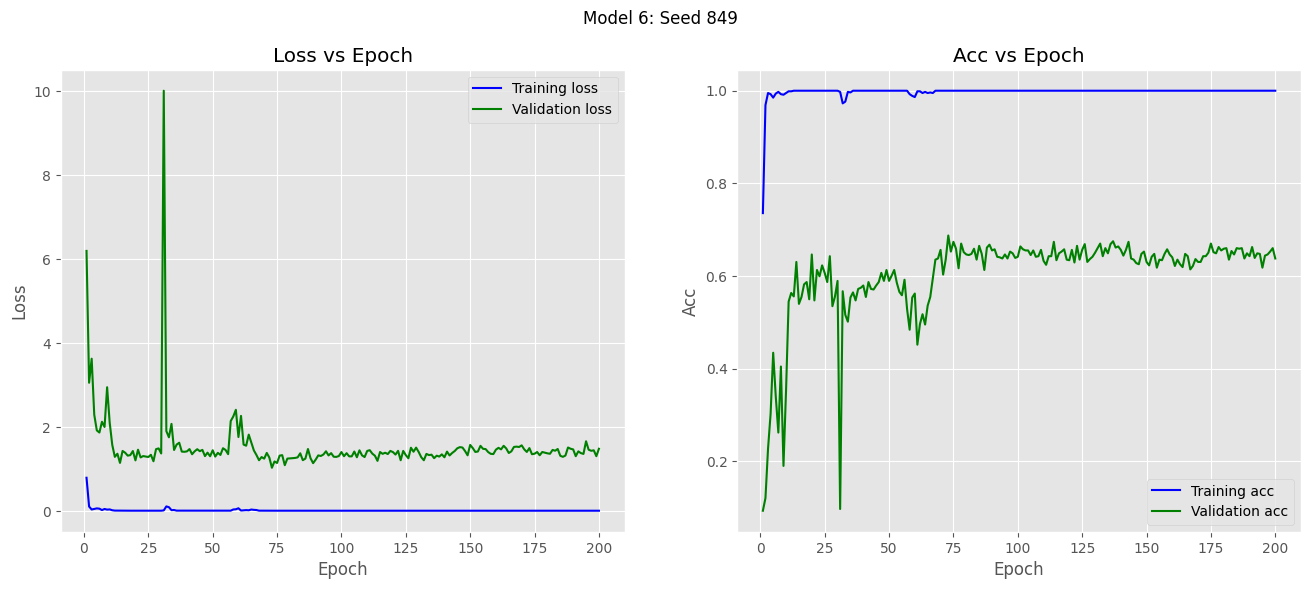

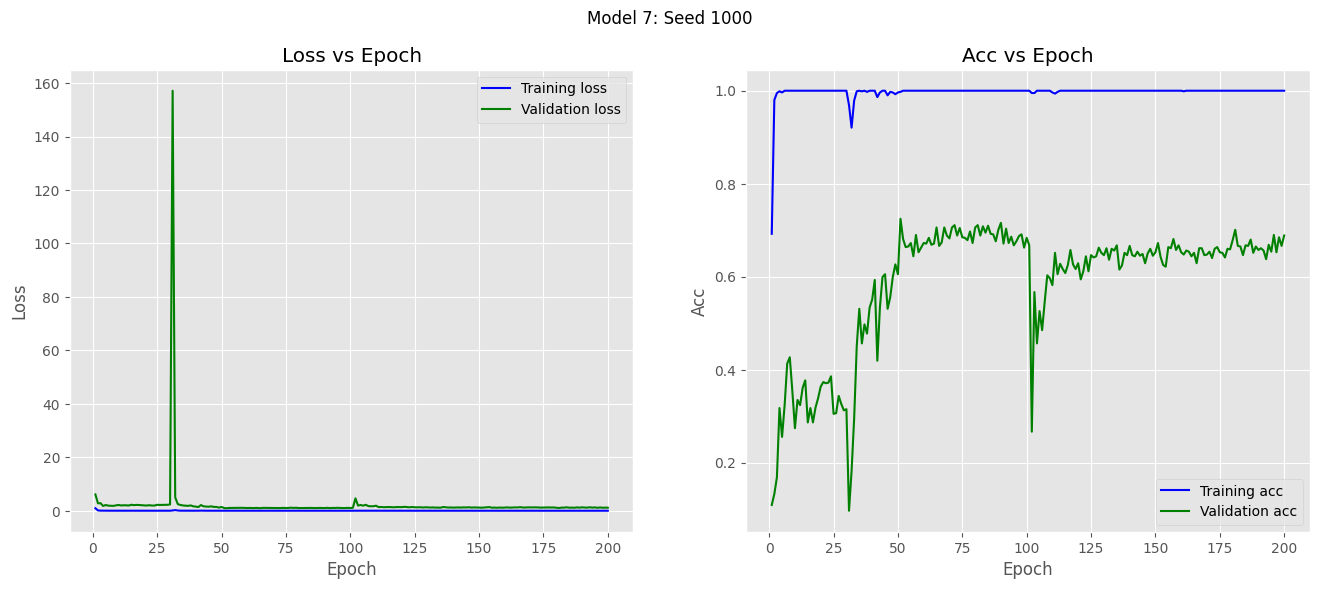

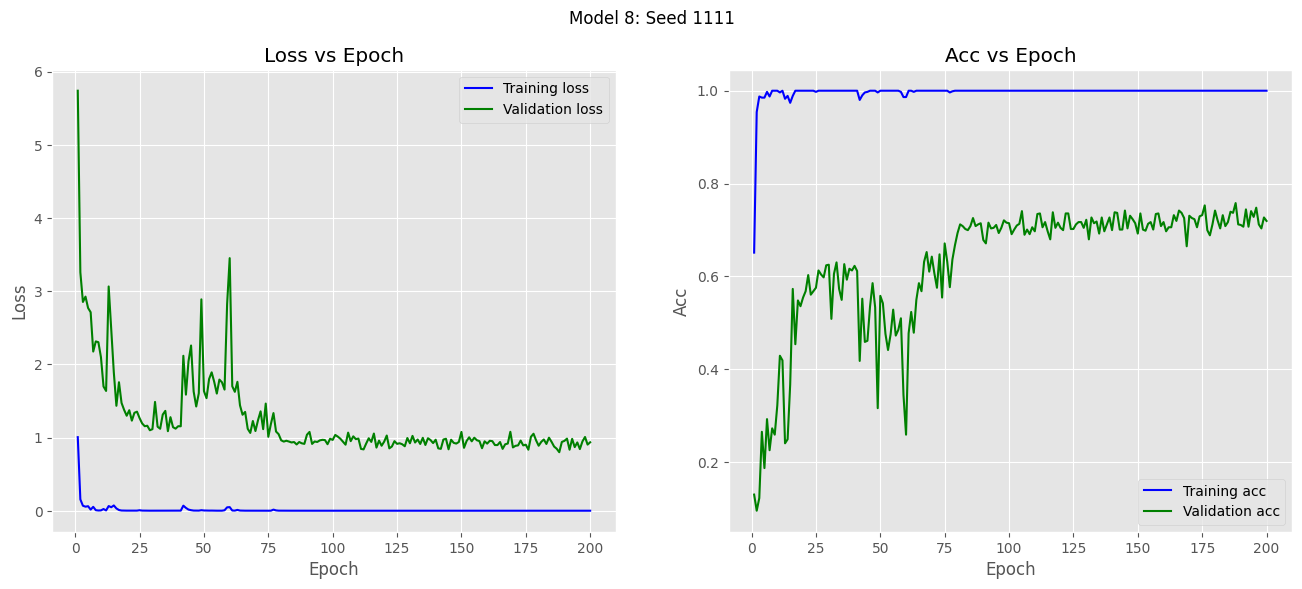

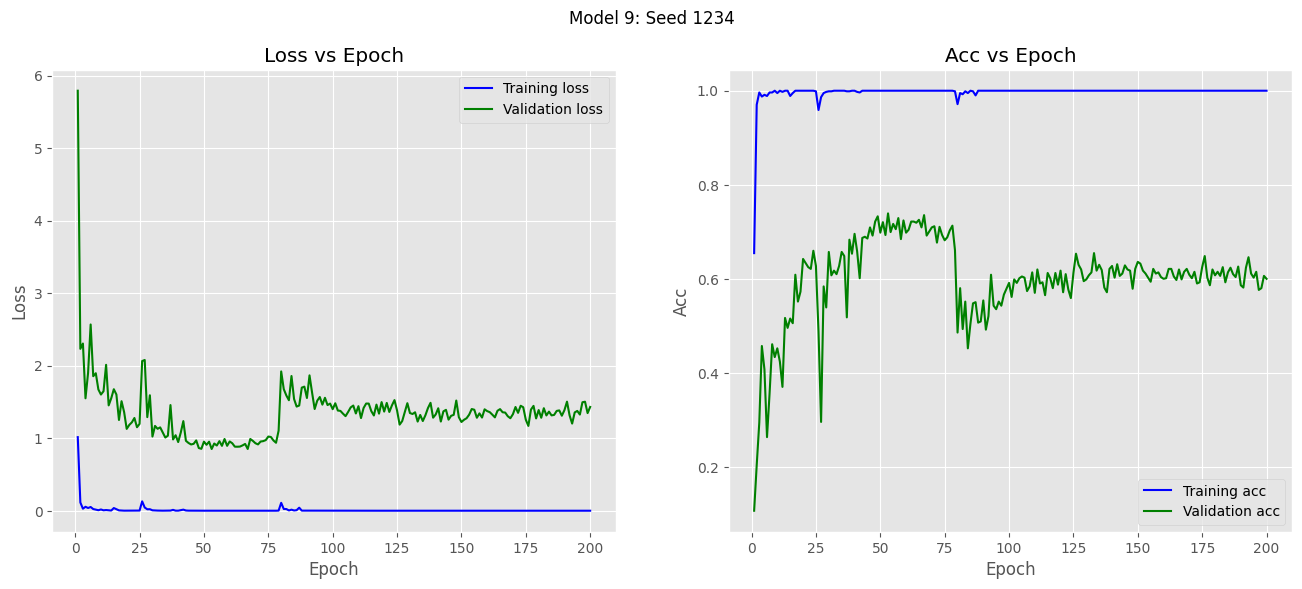

In [8]:
row, col = train_loss.shape

for i in range(row):
    
    with plt.style.context("ggplot"):
        fig = plt.figure(figsize = (16, 6))
    
        ax0 = fig.add_subplot(1, 2, 1)
        ax0.plot(np.arange(1, num_epochs+1), train_loss[i, :], label = "Training loss", c = "blue")
        ax0.plot(np.arange(1, num_epochs+1), val_loss[i, :], label = "Validation loss", c = "green")
        ax0.set_title("Loss vs Epoch")
        ax0.set_xlabel("Epoch")
        ax0.set_ylabel("Loss")
        ax0.legend()
        ax0.grid(True)
        
        ax1 = fig.add_subplot(1, 2, 2)
        ax1.plot(np.arange(1, num_epochs+1), train_acc[i, :], label = "Training acc", c = "blue")
        ax1.plot(np.arange(1, num_epochs+1), val_acc[i, :], label = "Validation acc", c = "green")
        ax1.set_title("Acc vs Epoch")
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("Acc")
        ax1.legend()
        ax1.grid(True)

        fig.suptitle(f"Model {i}: Seed {seed_lst[i]}")
        plt.show()

In [9]:
# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: Seed {seed}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    )
    
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Segmentation/Choi/wo_aug/rn18_seed{seed}_b16_speckle.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0: Seed 10
Test Accuracy: 0.5640
Evaluating Run 1: Seed 42
Test Accuracy: 0.7050
Evaluating Run 2: Seed 100
Test Accuracy: 0.6494
Evaluating Run 3: Seed 123
Test Accuracy: 0.6178
Evaluating Run 4: Seed 666
Test Accuracy: 0.3506
Evaluating Run 5: Seed 777
Test Accuracy: 0.4768
Evaluating Run 6: Seed 849
Test Accuracy: 0.5826
Evaluating Run 7: Seed 1000
Test Accuracy: 0.5900
Evaluating Run 8: Seed 1111
Test Accuracy: 0.6475
Evaluating Run 9: Seed 1234
Test Accuracy: 0.6122


In [10]:
test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Min: 35.0649
Max: 70.5009
Avg, Std: 57.9592, 9.5432
